<a href="https://www.kaggle.com/code/sonawanelalitsunil/salary-prediction-ml-97-30?scriptVersionId=263092423" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/salary-prediction-dataset/Salary_Data.csv


## Title:
Salary Prediction

## Description:
This dataset contains employee-related features such as education, experience, job role, and other factors that influence salary levels. It can be used to analyze patterns in compensation, build machine learning models to predict salaries, and explore the impact of different attributes on earning potential. Suitable for regression tasks, exploratory data analysis, and HR analytics.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/salary-prediction-dataset/Salary_Data.csv")

In [3]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
df.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0
6703,26.0,Female,High School,Sales Executive,1.0,35000.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [6]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [7]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [8]:
df.duplicated().sum()

4912

In [9]:
df.shape

(6704, 6)

In [10]:
df.dtypes

Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object

In [11]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

## Data visualizations

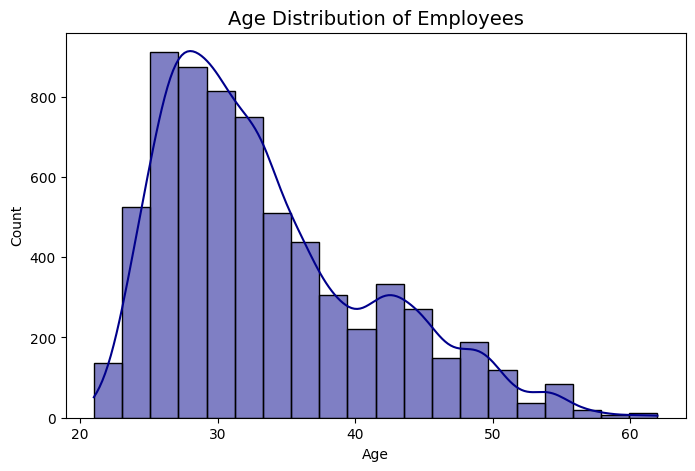

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], kde=True, bins=20, color="darkblue")
plt.title("Age Distribution of Employees", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

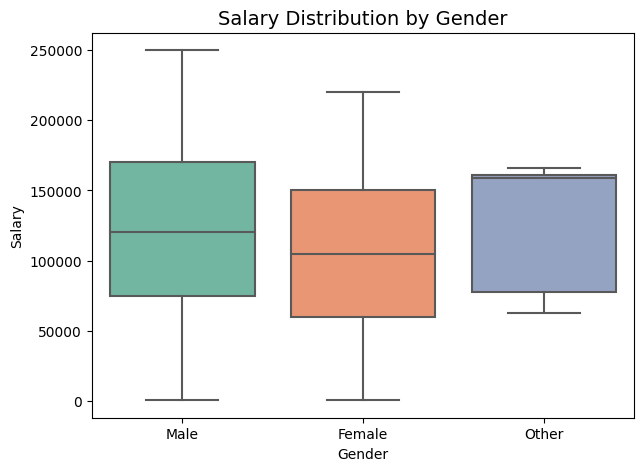

In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Gender", y="Salary", data=df, palette="Set2")
plt.title("Salary Distribution by Gender", fontsize=14)
plt.show()

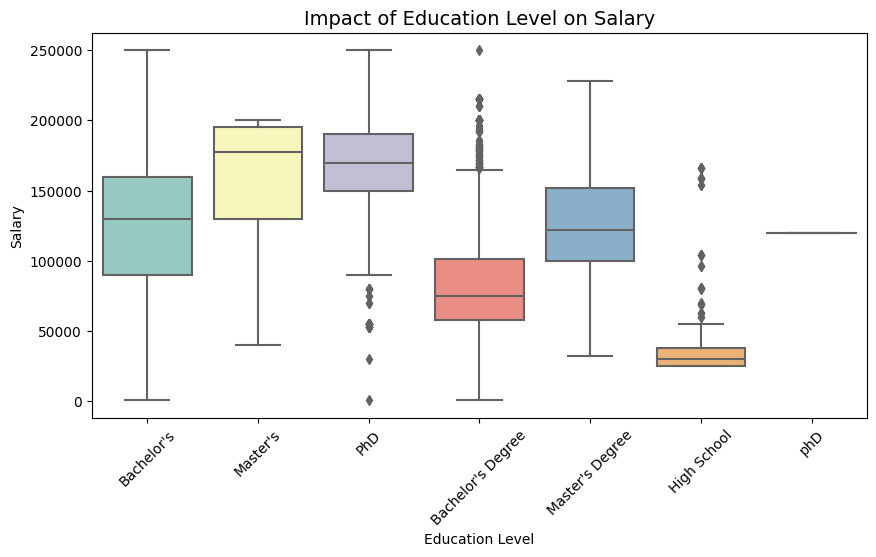

In [14]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Education Level", y="Salary", data=df, palette="Set3")
plt.title("Impact of Education Level on Salary", fontsize=14)
plt.xticks(rotation=45)
plt.show()

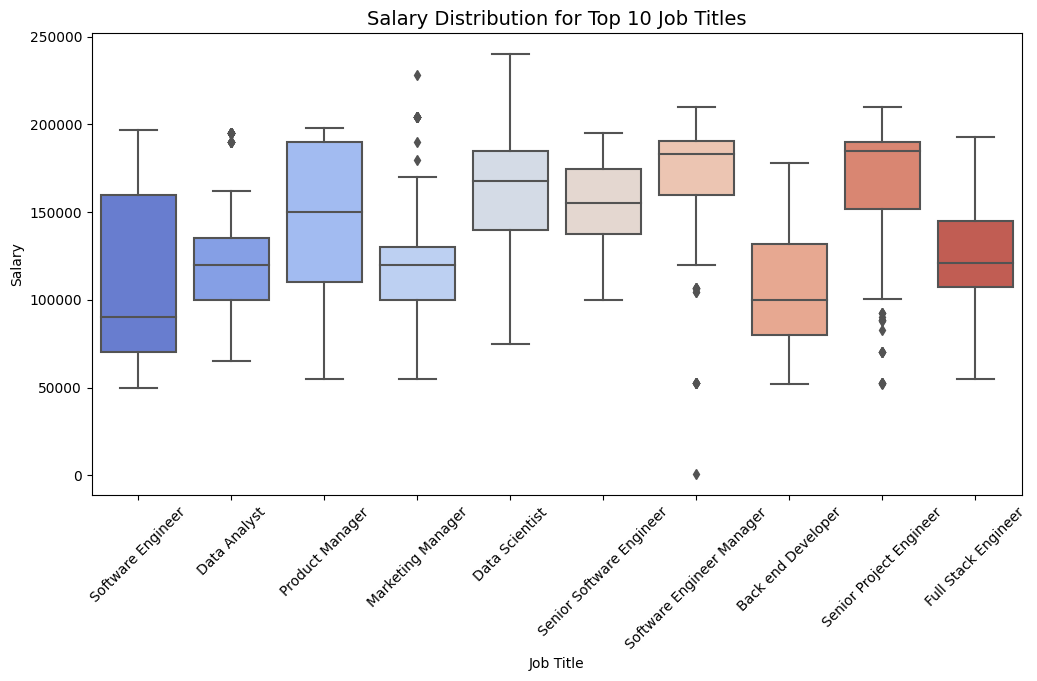

In [15]:
top_jobs = df["Job Title"].value_counts().nlargest(10).index
plt.figure(figsize=(12,6))
sns.boxplot(x="Job Title", y="Salary", data=df[df["Job Title"].isin(top_jobs)], palette="coolwarm")
plt.title("Salary Distribution for Top 10 Job Titles", fontsize=14)
plt.xticks(rotation=45)
plt.show()

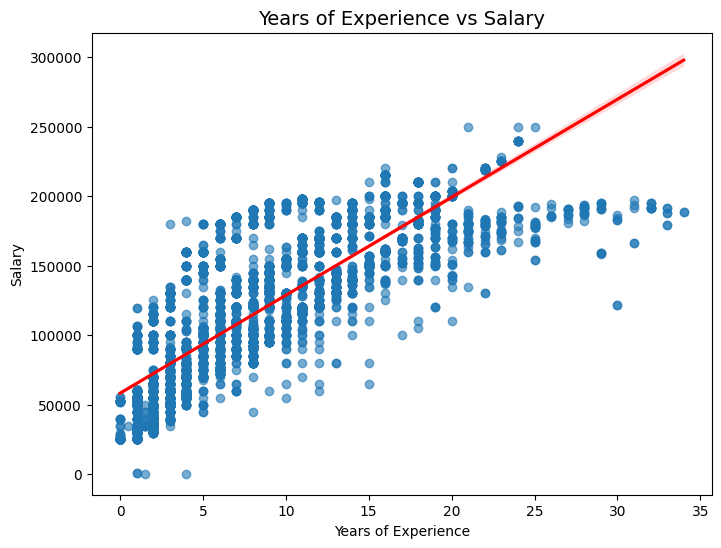

In [16]:
plt.figure(figsize=(8,6))
sns.regplot(x="Years of Experience", y="Salary", data=df, scatter_kws={'alpha':0.6}, line_kws={"color":"red"})
plt.title("Years of Experience vs Salary", fontsize=14)
plt.show()


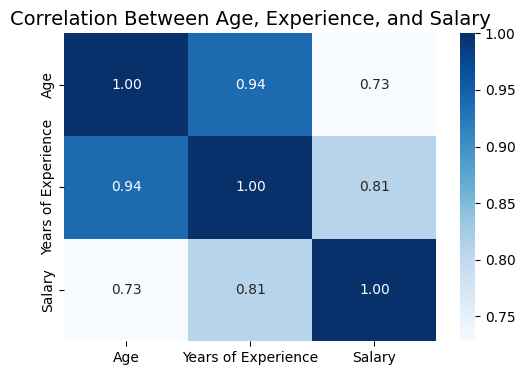

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(df[["Age","Years of Experience","Salary"]].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Between Age, Experience, and Salary", fontsize=14)
plt.show()

## ML Algorithms

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [19]:
le = LabelEncoder()
for col in ["Gender", "Education Level", "Job Title"]:
    df[col] = le.fit_transform(df[col])

In [20]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

In [21]:
imputer = SimpleImputer(strategy="mean")  # fill numeric NaN with mean
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
y = y.fillna(y.mean())

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "KNN Regressor": KNeighborsRegressor()
}

In [24]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = r2_score(y_test, y_pred) * 100  # R² as percentage
    results[name] = acc

In [25]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy (%)"])
print(results_df)

                      Model  Accuracy (%)
0         Linear Regression     66.563159
1             Decision Tree     96.531801
2             Random Forest     97.577540
3         Gradient Boosting     93.300245
4  Support Vector Regressor      0.144546
5             KNN Regressor     96.276376


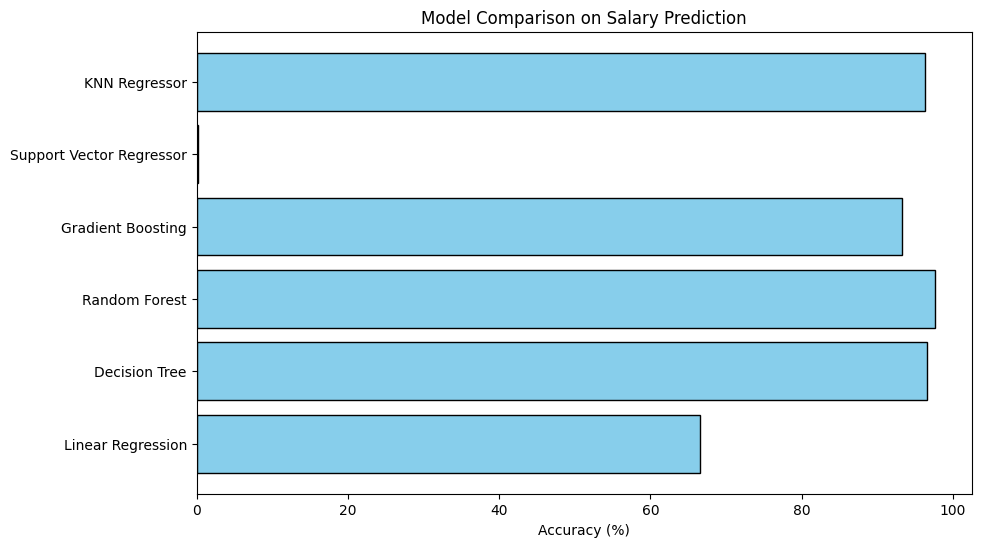

In [26]:
plt.figure(figsize=(10,6))
plt.barh(results_df["Model"], results_df["Accuracy (%)"], color="skyblue", edgecolor="black")
plt.xlabel("Accuracy (%)")
plt.title("Model Comparison on Salary Prediction")
plt.show()

## Thank you..pls upvote!!!